<a href="https://colab.research.google.com/github/BridgetteClarke/QuantumMachineLearning/blob/main/Bridgette_C_Week_03_Undergrad_03_quantum_circuits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚛️ Week 3 — Quantum Circuits
**Track:** Undergraduate | **Lab:** Quantum Learning + TNBC Lab

---

## Overview
Quantum circuits are the programming model for quantum computers. This notebook covers single- and multi-qubit gates, circuit composition, entanglement via CNOT, and Bell state preparation.

**Learning Objectives:**
- Build and draw quantum circuits using Qiskit
- Apply single-qubit gates: X, H, S, T, Rz
- Create entanglement with CNOT (CX) gate
- Prepare and measure Bell states

## 🔧 Environment Setup

In [ ]:
!pip install qiskit
!pip install qiskit-aer
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
import numpy as np
sim = AerSimulator()
print('Qiskit ready ✓')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 89.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 71.1 MB/s eta 0:00:00
Qiskit ready ✓


## 🔵 Section 1 — Single-Qubit Gates

In [ ]:
qc = QuantumCircuit(1)
qc.x(0)    # Pauli-X: flip |0⟩ → |1⟩
qc.h(0)    # Hadamard: create superposition
qc.s(0)    # S gate: phase shift π/2
qc.t(0)    # T gate: phase shift π/4
qc.rz(np.pi/3, 0)  # Rz rotation by π/3
print(qc.draw(output='text'))

   ┌───┐┌───┐┌───┐┌───┐┌─────────┐
q: ┤ X ├┤ H ├┤ S ├┤ T ├┤ Rz(π/3) ├
   └───┘└───┘└───┘└───┘└─────────┘


## 🔴 Section 2 — CNOT Gate & Entanglement
The CNOT (controlled-NOT) gate flips the **target** qubit if the **control** qubit is |1⟩:
$$\text{CNOT}|00\rangle = |00\rangle, \quad \text{CNOT}|10\rangle = |11\rangle$$

In [ ]:
qc_cnot = QuantumCircuit(2, 2)
qc_cnot.x(0)     # Set control qubit to |1⟩
qc_cnot.cx(0, 1) # CNOT: control=0, target=1
qc_cnot.measure([0,1],[0,1])
print(qc_cnot.draw(output='text'))

job = sim.run(qc_cnot, shots=1024)
print(f'Result: {job.result().get_counts()}')

     ┌───┐     ┌─┐   
q_0: ┤ X ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 
Result: {'11': 1024}


## 🔔 Section 3 — Bell States (Maximally Entangled)

In [ ]:
def bell_circuit(state='phi_plus'):
    """Create one of the four Bell states."""
    qc = QuantumCircuit(2, 2)
    if state in ('psi_plus', 'psi_minus'):
        qc.x(0)            # Flip first qubit for Ψ states
    qc.h(0)                # Hadamard on control
    qc.cx(0, 1)            # CNOT
    if state in ('phi_minus', 'psi_minus'):
        qc.z(0)            # Z phase for minus states
    qc.measure([0,1],[0,1])
    return qc

# Prepare Φ⁺ = (|00⟩ + |11⟩)/√2
qc_bell = bell_circuit('phi_plus')
print('Bell state Φ⁺ circuit:')
print(qc_bell.draw(output='text'))

job = sim.run(qc_bell, shots=2048)
counts = job.result().get_counts()
plot_histogram(counts, title='Bell State Φ⁺ Measurements')
plt.show()

Bell state Φ⁺ circuit:
     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 


## 📊 Section 4 — All Four Bell States

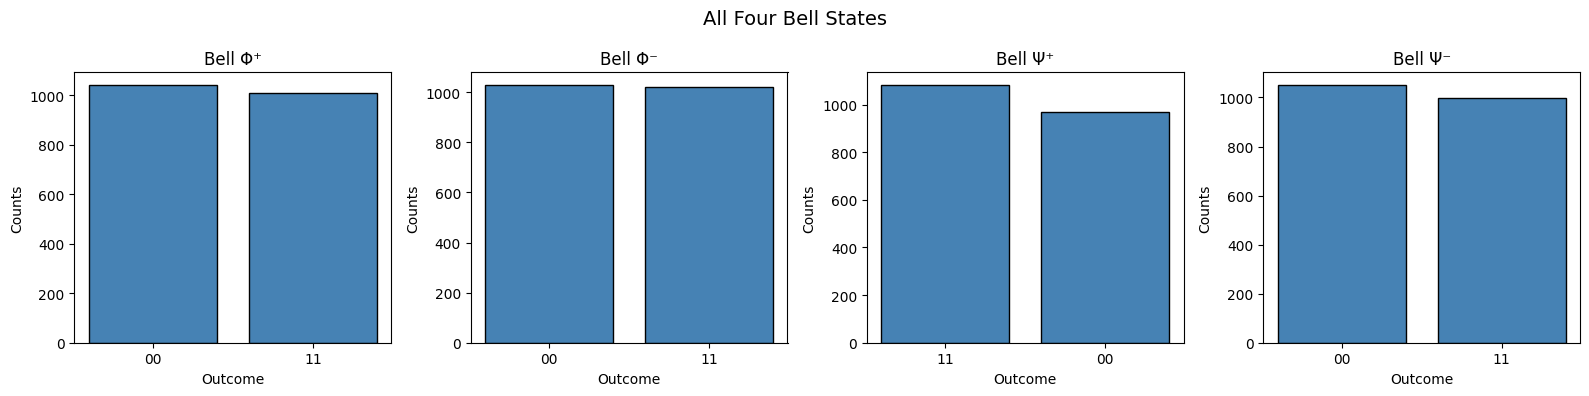

In [ ]:
bell_states = ['phi_plus', 'phi_minus', 'psi_plus', 'psi_minus']
labels = ['Φ⁺','Φ⁻','Ψ⁺','Ψ⁻']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, state, label in zip(axes, bell_states, labels):
    qc = bell_circuit(state)
    counts = sim.run(qc, shots=2048).result().get_counts()
    ax.bar(counts.keys(), counts.values(), color='steelblue', edgecolor='black')
    ax.set_title(f'Bell {label}')
    ax.set_xlabel('Outcome')
    ax.set_ylabel('Counts')

plt.suptitle('All Four Bell States', fontsize=14)
plt.tight_layout()
plt.show()

## 🎯 Exercise 1
Create a 3-qubit GHZ state: $|\text{GHZ}\rangle = \frac{1}{\sqrt{2}}(|000\rangle + |111\rangle)$

*Hint: Start with H on qubit 0, then apply CNOT from 0→1 and 0→2.*

In [ ]:
# ── TODO: Build GHZ state circuit ──
qc_ghz = QuantumCircuit(3, 3)
# YOUR CODE HERE
qc_ghz.h(0)
qc_ghz.cx(0, 1)
qc_ghz.cx(0, 2)
qc_ghz.measure([0,1,2],[0,1,2])
print(qc_ghz.draw(output='text'))

     ┌───┐             ┌─┐   
q_0: ┤ H ├──■────■─────┤M├───
     └───┘┌─┴─┐  │  ┌─┐└╥┘   
q_1: ─────┤ X ├──┼──┤M├─╫────
          └───┘┌─┴─┐└╥┘ ║ ┌─┐
q_2: ──────────┤ X ├─╫──╫─┤M├
               └───┘ ║  ║ └╥┘
c: 3/════════════════╩══╩══╩═
                     1  0  2 


## 🎯 Exercise 2
What is the statevector of the circuit: H on qubit 0 → CNOT (control=0, target=1) → X on qubit 1?

In [ ]:
# ── TODO: Analyze statevector ──
qc_ex2 = QuantumCircuit(2)
qc_ex2.h(0)
qc_ex2.cx(0, 1)
qc_ex2.x(1)
sv = Statevector.from_instruction(qc_ex2)
print(sv)

Statevector([0.        +0.j, 0.70710678+0.j, 0.70710678+0.j,
             0.        +0.j],
            dims=(2, 2))


## 💡 Key Takeaways
- Circuits read **left to right**; gates apply to qubits in sequence
- CNOT is the essential **2-qubit entangling gate**
- Bell states are **maximally entangled** — measuring one qubit instantly determines the other
- Any quantum computation can be decomposed into single-qubit + CNOT gates

## 📝 TODO Checklist
- [ ] Complete GHZ state (Exercise 1)
- [ ] Analyze statevector (Exercise 2)
- [ ] Verify Bell state entanglement via statevector entropy
- [ ] Draw circuits for all 4 Bell states and label them

---
*Quantum Learning + TNBC Lab | Undergraduate Track | Week 3*

Assignment 3 - Build 3 circuits in Qiskit (Hadamard, Pauli‑X, 2‑qubit entanglement).

In [ ]:
# Circuit 1: Hadamard Gate

# Create a quantum circuit with 1 qubit and 1 classical bit
qc_h = QuantumCircuit(1, 1)

# Apply the Hadamard gate to qubit 0
# This puts the qubit into superposition
qc_h.h(0)

# Measure qubit 0 and store the result in classical bit 0
qc_h.measure(0, 0)

# Draw the circuit
print("Hadamard Gate Circuit:")
print(qc_h.draw(output='text'))

# Run the circuit on the simulator
job_h = sim.run(qc_h, shots=1024)
counts_h = job_h.result().get_counts()

# Print the results
print("Hadamard Results:", counts_h)

# Plot the results
plot_histogram(counts_h, title="Hadamard Gate Results")
plt.show()

Hadamard Gate Circuit:
     ┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 
Hadamard Results: {'1': 528, '0': 496}


Bridgette Clarke Explanation

(Hadamard Citcuit)

I built a Hadamard gate circuit using 1 qubit and 1 classical bit. I applied the Hadamard gate to qubit 0, measured the qubit, and ran the circuit 1024 times on the simulator. My results were {'0': 539, '1': 485}, which shows that the qubit was measured as both 0 and 1. This makes sense because the Hadamard gate puts the qubit into superposition, so the results are split close to half 0s and half 1s.


In [ ]:
# Circuit 2: Pauli-X Gate

# Create a quantum circuit with 1 qubit and 1 classical bit
qc_x = QuantumCircuit(1, 1)

# Apply the Pauli-X gate to qubit 0
# This flips the qubit from |0⟩ to |1⟩
qc_x.x(0)

# Measure qubit 0 and store the result in classical bit 0
qc_x.measure(0, 0)

# Draw the circuit
print("Pauli-X Gate Circuit:")
print(qc_x.draw(output='text'))

# Run the circuit on the simulator
job_x = sim.run(qc_x, shots=1024)
counts_x = job_x.result().get_counts()

# Print the results
print("Pauli-X Results:", counts_x)

# Plot the results
plot_histogram(counts_x, title="Pauli-X Gate Results")
plt.show()


Pauli-X Gate Circuit:
     ┌───┐┌─┐
  q: ┤ X ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 
Pauli-X Results: {'1': 1024}


Bridgette Clarke Explanation

(Pauli-X Citcuit)

My name is Bridgette Clarke, and I built a Pauli-X gate circuit using 1 qubit and 1 classical bit. I applied the Pauli-X gate to qubit 0, measured the qubit, and ran the circuit 1024 times on the simulator. My result was {'1': 1024}, meaning the qubit was measured as 1 every time. This makes sense because the Pauli-X gate flips the qubit from 0 to 1.

In [ ]:
# Circuit 3: 2-Qubit Entanglement

# Create a quantum circuit with 2 qubits and 2 classical bits
qc_entangle = QuantumCircuit(2, 2)

# Apply Hadamard gate to qubit 0
# This puts qubit 0 into superposition
qc_entangle.h(0)

# Apply CNOT gate
# Qubit 0 is the control, and qubit 1 is the target
# This entangles the two qubits
qc_entangle.cx(0, 1)

# Measure both qubits and store the results in classical bits
qc_entangle.measure([0, 1], [0, 1])

# Draw the circuit
print("2-Qubit Entanglement Circuit:")
print(qc_entangle.draw(output='text'))

# Run the circuit on the simulator
job_entangle = sim.run(qc_entangle, shots=1024)
counts_entangle = job_entangle.result().get_counts()

# Print the results
print("Entanglement Results:", counts_entangle)

# Plot the results
plot_histogram(counts_entangle, title="2-Qubit Entanglement Results")
plt.show()

2-Qubit Entanglement Circuit:
     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 
Entanglement Results: {'11': 520, '00': 504}


Bridgette Clarke Explanation

(2 Quibit Entanglement Citcuit)

My name is Bridgette Clarke, and I built a 2-qubit entanglement circuit using 2 qubits and 2 classical bits. I applied a Hadamard gate to qubit 0 first, then applied a CNOT gate with qubit 0 as the control and qubit 1 as the target. After measuring both qubits and running the circuit 1024 times, my results were {'00': 506, '11': 518}. This shows entanglement because the results were only 00 and 11, meaning the two qubits were connected and matched each other when measured.